In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.float_format', '{:,.0f}'.format)

Mounted at /content/drive


In [ ]:
%cd "drive/MyDrive/Colab Notebooks/MIS 769/AnalyzeMe1"

/content/drive/MyDrive/Colab Notebooks/MIS 769/AnalyzeMe1


In [ ]:
print(os.listdir())

['fraud_data.csv', 'AnalyzeMe1 Plan.gdoc', 'AnalyzeMe1 - OGDE1.ipynb', 'AnalyzeMe1 - OGDE2.ipynb', 'AnalyzeMe1 - Initial DE.ipynb', 'ieee-fd']


In [ ]:
# Load the main transaction table
train_t_df = pd.read_csv('ieee-fd/train_transaction.csv')

# Load the identity table (only a subset of transactions have this info)
train_i_df = pd.read_csv('ieee-fd/train_identity.csv')

# Optional quick checks after loading
print("Transaction shape:", train_t_df.shape)
print("Identity shape:   ", train_i_df.shape)

Transaction shape: (590540, 394)
Identity shape:    (144233, 41)


In [ ]:
print("\nTransaction columns preview:")
print(train_t_df.columns[:20].tolist())  # first 20 columns


Transaction columns preview:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3']


In [ ]:
print("\nBasic info:")
train_i_df.info()


Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          1

In [ ]:
train_i_df.head(10)

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0,"70,787",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5,"98,945",NaN,NaN,0,-5,NaN,NaN,NaN,...,mobile safari 11.0,32,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5,"191,631",0,0,0,0,NaN,NaN,0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5,"221,832",NaN,NaN,0,-6,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0,"7,460",0,0,1,0,NaN,NaN,0,...,chrome 62.0,24,1280x800,match_status:2,T,F,T,T,desktop,MacOS
5,2987017,-5,"61,141",3,0,3,0,NaN,NaN,3,...,chrome 62.0,24,1366x768,match_status:2,T,F,T,T,desktop,Windows
6,2987022,-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987038,0,"31,964",0,0,0,-10,NaN,NaN,0,...,chrome 62.0,32,1920x1080,match_status:2,T,F,T,T,mobile,NaN
8,2987040,-10,"116,098",0,0,0,0,NaN,NaN,0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
9,2987048,-5,"257,037",NaN,NaN,0,0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows


In [ ]:
# Create the filtered DataFrame (rows where DeviceInfo is present)
train_i_DI_nonnull = train_i_df[train_i_df['DeviceInfo'].notnull()].copy()

# Quick checks to verify
print("Original identity shape:", train_i_df.shape)
print("Rows with DeviceInfo not null:", train_i_DI_nonnull.shape)
print("\nMissing DeviceInfo in the new df (should be 0):", train_i_DI_nonnull['DeviceInfo'].isnull().sum())

# Optional: preview first few rows
print("\nFirst 5 rows of non-null DeviceInfo:")
print(train_i_DI_nonnull[['TransactionID', 'DeviceType', 'DeviceInfo']].head())

Original identity shape: (144233, 41)
Rows with DeviceInfo not null: (118666, 41)

Missing DeviceInfo in the new df (should be 0): 0

First 5 rows of non-null DeviceInfo:
   TransactionID DeviceType                     DeviceInfo
0        2987004     mobile  SAMSUNG SM-G892A Build/NRD90M
1        2987008     mobile                     iOS Device
2        2987010    desktop                        Windows
4        2987016    desktop                          MacOS
5        2987017    desktop                        Windows


In [ ]:
print("\nDI_nonnull Basic info:")
train_i_DI_nonnull.info()


DI_nonnull Basic info:
<class 'pandas.core.frame.DataFrame'>
Index: 118666 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  118666 non-null  int64  
 1   id_01          118666 non-null  float64
 2   id_02          118666 non-null  float64
 3   id_03          58643 non-null   float64
 4   id_04          58643 non-null   float64
 5   id_05          115313 non-null  float64
 6   id_06          115313 non-null  float64
 7   id_07          4527 non-null    float64
 8   id_08          4527 non-null    float64
 9   id_09          66260 non-null   float64
 10  id_10          66260 non-null   float64
 11  id_11          118666 non-null  float64
 12  id_12          118666 non-null  object 
 13  id_13          103295 non-null  float64
 14  id_14          77285 non-null   float64
 15  id_15          118666 non-null  object 
 16  id_16          116218 non-null  object 
 17  id_17     

In [ ]:
# Create a new df with both DeviceInfo and DeviceType non-null
train_i_dense_device = train_i_DI_nonnull[
    train_i_DI_nonnull['DeviceInfo'].notnull() &
    train_i_DI_nonnull['DeviceType'].notnull()
].copy()

# Quick checks
print("Rows after requiring both DeviceInfo and DeviceType non-null:", train_i_dense_device.shape[0])

print("\nNon-null count for DeviceType in this new df:", train_i_dense_device['DeviceType'].notnull().sum())
print("Non-null count for DeviceInfo in this new df:", train_i_dense_device['DeviceInfo'].notnull().sum())

# Now drop columns that still have any nulls in this subset
full_cols_now = train_i_dense_device.columns[train_i_dense_device.notnull().all()].tolist()

train_i_dense_both = train_i_dense_device[full_cols_now].copy()

print("\nShape after dropping any remaining partially-null columns:", train_i_dense_both.shape)
print("Kept columns:", full_cols_now)

Rows after requiring both DeviceInfo and DeviceType non-null: 118621

Non-null count for DeviceType in this new df: 118621
Non-null count for DeviceInfo in this new df: 118621

Shape after dropping any remaining partially-null columns: (118621, 14)
Kept columns: ['TransactionID', 'id_01', 'id_02', 'id_11', 'id_12', 'id_15', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [ ]:
train_i_dense_both.tail(10)

,TransactionID,id_01,id_02,id_11,id_12,id_15,id_28,id_29,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
144223,3577495,-5,"56,061",100,Found,Found,Found,Found,T,F,T,T,desktop,Windows
144224,3577499,-5,"89,753",100,NotFound,Found,Found,Found,F,F,T,F,desktop,Windows
144225,3577501,-5,"59,763",100,NotFound,Found,Found,Found,F,F,T,F,desktop,Windows
144226,3577506,0,"82,599",100,NotFound,Found,Found,Found,T,T,T,T,desktop,Trident/7.0
144227,3577509,-5,"253,305",100,NotFound,Found,Found,Found,F,F,T,F,mobile,SM-G930F Build/NRD90M
144228,3577521,-15,"145,955",100,NotFound,Found,Found,Found,F,F,T,F,mobile,F3111 Build/33.3.A.1.97
144229,3577526,-5,"172,059",100,NotFound,New,New,NotFound,T,F,T,F,mobile,A574BL Build/NMF26F
144230,3577529,-20,"632,381",100,NotFound,New,New,NotFound,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152
144231,3577531,-5,"55,528",100,NotFound,Found,Found,Found,T,F,T,F,desktop,MacOS
144232,3577534,-45,"339,406",100,NotFound,New,New,NotFound,F,F,T,F,mobile,RNE-L03 Build/HUAWEIRNE-L03


In [ ]:
for col in train_i_dense_both.columns:
    unique_count = train_i_dense_both[col].nunique()
    print(f"{col}: {unique_count} unique values")

TransactionID: 118621 unique values
id_01: 72 unique values
id_02: 99150 unique values
id_11: 362 unique values
id_12: 2 unique values
id_15: 3 unique values
id_28: 2 unique values
id_29: 2 unique values
id_35: 2 unique values
id_36: 2 unique values
id_37: 2 unique values
id_38: 2 unique values
DeviceType: 2 unique values
DeviceInfo: 1786 unique values


In [ ]:
# Option 1: Simple and clean (recommended)
top_deviceinfo = train_i_dense_both['DeviceInfo'].value_counts().head(10)

print("\nTop 10 DeviceInfo:")
for device, count in top_deviceinfo.items():
    print(f"{device:40} : {count:6,} occurrences")


Top 10 DeviceInfo:
Windows                                  : 47,720 occurrences
iOS Device                               : 19,782 occurrences
MacOS                                    : 12,573 occurrences
Trident/7.0                              :  7,434 occurrences
rv:11.0                                  :  1,864 occurrences
rv:57.0                                  :    962 occurrences
SM-J700M Build/MMB29K                    :    549 occurrences
SM-G610M Build/MMB29K                    :    461 occurrences
SM-G531H Build/LMY48B                    :    410 occurrences
rv:59.0                                  :    362 occurrences


In [ ]:
top10 = train_i_dense_both['DeviceInfo'].value_counts().head(10)
total_rows = len(train_i_dense_both)

print("Top 10 DeviceInfo values:")
print(top10)
print("\nWith percentages:")
print((top10 / total_rows * 100).round(2).astype(str) + '%')

Top 10 DeviceInfo values:
DeviceInfo
Windows                  47720
iOS Device               19782
MacOS                    12573
Trident/7.0               7434
rv:11.0                   1864
rv:57.0                    962
SM-J700M Build/MMB29K      549
SM-G610M Build/MMB29K      461
SM-G531H Build/LMY48B      410
rv:59.0                    362
Name: count, dtype: int64

With percentages:
DeviceInfo
Windows                  40.23%
iOS Device               16.68%
MacOS                     10.6%
Trident/7.0               6.27%
rv:11.0                   1.57%
rv:57.0                   0.81%
SM-J700M Build/MMB29K     0.46%
SM-G610M Build/MMB29K     0.39%
SM-G531H Build/LMY48B     0.35%
rv:59.0                   0.31%
Name: count, dtype: object


In [ ]:
def simplify_device(info):
    if pd.isna(info):
        return 'Missing'  # or 'Other' if you prefer
    info_str = str(info).lower()
    if 'windows' in info_str:
        return 'Windows'
    elif 'ios' in info_str or 'iphone' in info_str or 'ipad' in info_str:
        return 'iOS'
    elif 'mac' in info_str or 'os x' in info_str or 'macos' in info_str:
        return 'MacOS'
    else:
        return 'Other'

# Apply it to create the new grouped column
train_i_dense_both['DeviceInfo_grouped'] = train_i_dense_both['DeviceInfo'].apply(simplify_device)

# Quick check of the new distribution
print("Grouped DeviceInfo distribution:")
print(train_i_dense_both['DeviceInfo_grouped'].value_counts())
print("\nAs percentages:")
print(train_i_dense_both['DeviceInfo_grouped'].value_counts(normalize=True).round(4) * 100)

Grouped DeviceInfo distribution:
DeviceInfo_grouped
Windows    47773
Other      38491
iOS        19783
MacOS      12574
Name: count, dtype: int64

As percentages:
DeviceInfo_grouped
Windows   40
Other     32
iOS       17
MacOS     11
Name: proportion, dtype: float64


In [ ]:
def group_device_advanced(info):
    if pd.isna(info):
        return 'Missing'
    s = str(info).lower()
    if 'windows' in s or 'trident' in s:
        return 'Windows / Trident'
    elif 'ios' in s:
        return 'iOS'
    elif 'mac' in s or 'os x' in s or 'macos' in s:
        return 'MacOS'
    elif s.startswith('rv:'):
        return 'Firefox rv: (old)'
    elif s.startswith('sm-'):
        return 'Samsung SM-'
    else:
        return 'Other'

# Create the new grouped column
train_i_dense_both['DeviceInfo_grouped_adv'] = train_i_dense_both['DeviceInfo'].apply(group_device_advanced)

# View the new distribution
print("New grouped distribution:")
print(train_i_dense_both['DeviceInfo_grouped_adv'].value_counts())

print("\nWith percentages:")
print(
    train_i_dense_both['DeviceInfo_grouped_adv']
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
      .astype(str) + ' %'
)

New grouped distribution:
DeviceInfo_grouped_adv
Windows / Trident    55207
iOS                  19782
Other                17462
MacOS                12574
Samsung SM-           9248
Firefox rv: (old)     4348
Name: count, dtype: int64

With percentages:
DeviceInfo_grouped_adv
Windows / Trident    46.54 %
iOS                  16.68 %
Other                14.72 %
MacOS                 10.6 %
Samsung SM-            7.8 %
Firefox rv: (old)     3.67 %
Name: proportion, dtype: object


In [ ]:
train_t_df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68,W,13926,NaN,150,discover,142,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29,W,2755,404,150,mastercard,102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59,W,4663,490,150,visa,166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50,W,18132,567,150,mastercard,117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50,H,4497,514,150,mastercard,102,...,0,0,0,0,0,0,0,0,0,0
5,2987005,0,86510,49,W,5937,555,150,visa,226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159,W,12308,360,150,visa,166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422,W,12695,490,150,visa,226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15,H,2803,100,150,visa,226,...,0,0,0,0,0,0,0,0,0,0
9,2987009,0,86536,117,W,17399,111,150,mastercard,224,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Shape:", train_t_df.shape)
print("\nFraud rate:")
print(train_t_df['isFraud'].value_counts(normalize=True).mul(100).round(2), "%")

print("\nMissing % by column (top 20 highest):")
print(train_t_df.isna().mean().sort_values(ascending=False).head(20).round(4)*100)

Shape: (590540, 394)

Fraud rate:
isFraud
0   96
1    4
Name: proportion, dtype: float64 %

Missing % by column (top 20 highest):
dist2   94
D7      93
D13     90
D14     89
D12     89
D6      88
D9      87
D8      87
V153    86
V149    86
V141    86
V146    86
V154    86
V162    86
V142    86
V158    86
V161    86
V157    86
V138    86
V139    86
dtype: float64


In [ ]:
named_cols = [
    'TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
    'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2', 'dist1', 'dist2',
    'P_emaildomain', 'R_emaildomain'
] + [f'M{i}' for i in range(1,10)]

print("Named columns present:", [c for c in named_cols if c in train_t_df.columns])

# Quick summaries
print("\nTransactionAmt stats:")
print(train_t_df['TransactionAmt'].describe().round(2))

print("\nProductCD distribution:")
print(train_t_df['ProductCD'].value_counts(dropna=False))

print("\nCard brand (card4):")
print(train_t_df['card4'].value_counts(dropna=False))

print("\nCard type (card6):")
print(train_t_df['card6'].value_counts(dropna=False))

print("\nTop email domains (P_emaildomain):")
print(train_t_df['P_emaildomain'].value_counts().head(15))

print("\nDist1 / Dist2 quick look:")
print(train_t_df[['dist1','dist2']].describe().round(2))

Named columns present: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

TransactionAmt stats:
count   590,540
mean        135
std         239
min           0
25%          43
50%          69
75%         125
max      31,937
Name: TransactionAmt, dtype: float64

ProductCD distribution:
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

Card brand (card4):
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64

Card type (card6):
card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64

Top email domains (P_emaildomain):
P_email

In [ ]:
# Fraud rate when dist2 present vs missing
print("Fraud rate overall:", train_t_df['isFraud'].mean().round(4)*100, "%")
print("\nFraud rate when dist2 present:")
print(train_t_df[train_t_df['dist2'].notnull()]['isFraud'].mean().round(4)*100, "%")
print("Fraud rate when dist2 missing:")
print(train_t_df[train_t_df['dist2'].isnull()]['isFraud'].mean().round(4)*100, "%")

Fraud rate overall: 3.5000000000000004 %

Fraud rate when dist2 present:
9.92 %
Fraud rate when dist2 missing:
3.06 %


In [ ]:
# 1. First create the trimmed DataFrame (using the columns we discussed earlier)
keep_cols = [
    'TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
    'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2', 'dist1', 'dist2',
    'P_emaildomain', 'R_emaildomain'
] + [f'M{i}' for i in range(1,10)]

train_t_trimmed = train_t_df[keep_cols].copy()

# 2. Now add the has_dist2 flag
train_t_trimmed['has_dist2'] = train_t_df['dist2'].notnull().astype(int)

# 3. Verify the result
print("Fraud rate by has_dist2:")
print(train_t_trimmed.groupby('has_dist2')['isFraud'].mean().mul(100).round(2))
print("\nCounts:")
print(train_t_trimmed['has_dist2'].value_counts())

Fraud rate by has_dist2:
has_dist2
0    3
1   10
Name: isFraud, dtype: float64

Counts:
has_dist2
0    552913
1     37627
Name: count, dtype: int64


In [ ]:
# Drop the original sparse column
train_t_trimmed = train_t_trimmed.drop(columns=['dist2'], errors='ignore')

In [ ]:
train_t_trimmed.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,M2,M3,M4,M5,M6,M7,M8,M9,has_dist2,has_dist1
0,2987000,0,86400,68,W,13926,NaN,150,discover,142,...,T,T,M2,F,T,NaN,NaN,NaN,0,1
1,2987001,0,86401,29,W,2755,404,150,mastercard,102,...,NaN,NaN,M0,T,T,NaN,NaN,NaN,0,0
2,2987002,0,86469,59,W,4663,490,150,visa,166,...,T,T,M0,F,F,F,F,F,0,1
3,2987003,0,86499,50,W,18132,567,150,mastercard,117,...,NaN,NaN,M0,T,F,NaN,NaN,NaN,0,0
4,2987004,0,86506,50,H,4497,514,150,mastercard,102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [ ]:
print("Fraud rate when dist1 present vs missing:")
print(train_t_trimmed.groupby(train_t_trimmed['dist1'].notnull())['isFraud'].mean().mul(100).round(2))

Fraud rate when dist1 present vs missing:
dist1
False   5
True    2
Name: isFraud, dtype: float64


In [ ]:
print("dist1 statistics by fraud status (including missing as NaN):")
print(train_t_trimmed.groupby('isFraud')['dist1'].describe().round(2))

print("\nOnly among rows where dist1 is present (non-null):")
non_null = train_t_trimmed[train_t_trimmed['dist1'].notnull()]
print(non_null.groupby('isFraud')['dist1'].describe().round(2))

dist1 statistics by fraud status (including missing as NaN):
          count  mean  std  min  25%  50%  75%    max
isFraud                                              
0       233,514   117  371    0    3    8   24 10,286
1         4,755   175  424    0    3   10   86  4,942

Only among rows where dist1 is present (non-null):
          count  mean  std  min  25%  50%  75%    max
isFraud                                              
0       233,514   117  371    0    3    8   24 10,286
1         4,755   175  424    0    3   10   86  4,942


In [ ]:
# 1. Add has_dist1 flag (1 = present, 0 = missing)
train_t_trimmed['has_dist1'] = train_t_trimmed['dist1'].notnull().astype(int)

# 2. Drop the raw dist1 column
train_t_trimmed = train_t_trimmed.drop(columns=['dist1'], errors='ignore')

# Quick verification of flags
print("Fraud rates by flags:")
print(train_t_trimmed.groupby('has_dist1')['isFraud'].mean().mul(100).round(2))
print(train_t_trimmed.groupby('has_dist2')['isFraud'].mean().mul(100).round(2))

Fraud rates by flags:
has_dist1
0   5
1   2
Name: isFraud, dtype: float64
has_dist2
0    3
1   10
Name: isFraud, dtype: float64


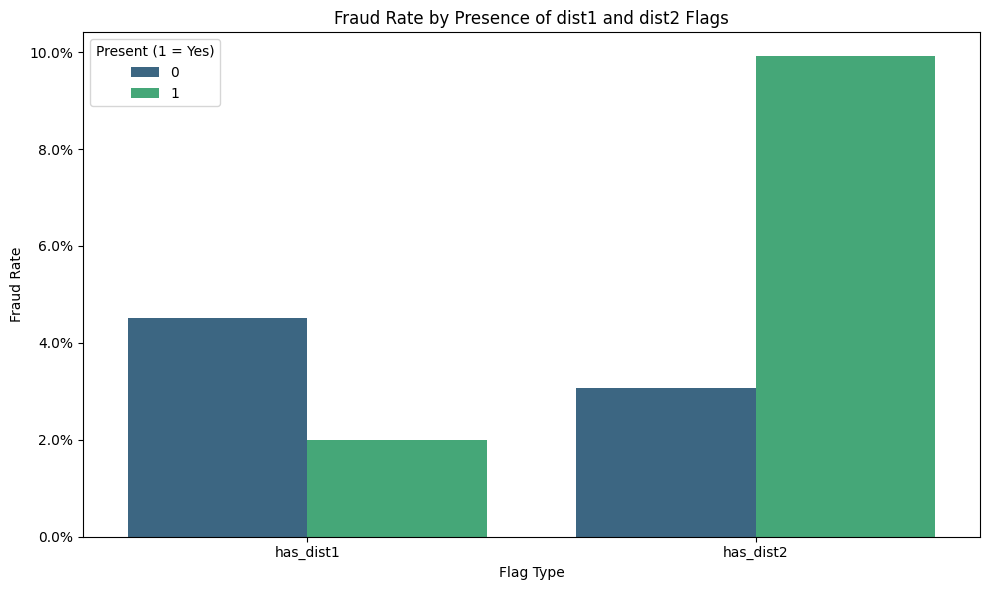

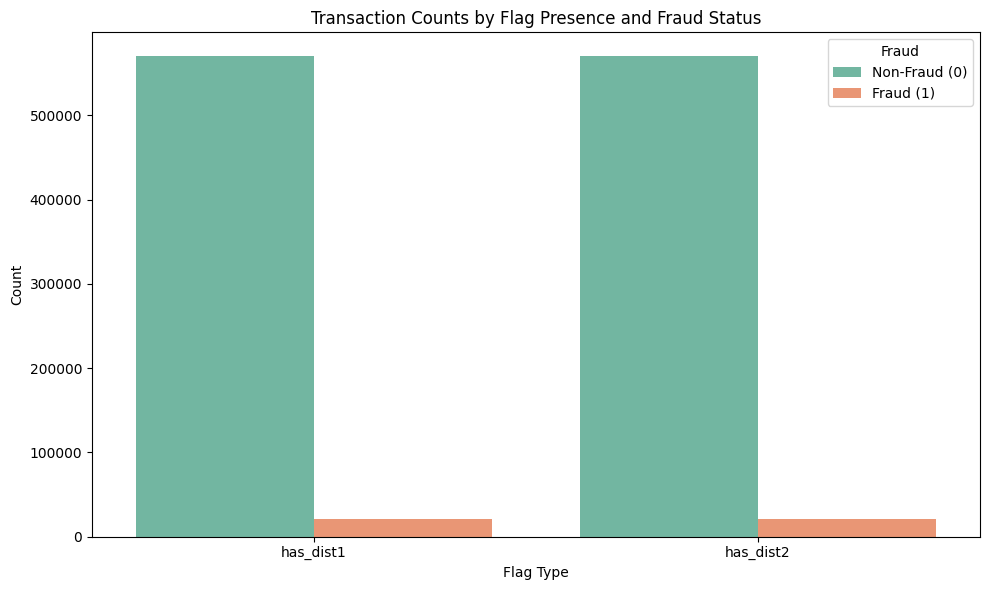

In [ ]:
# Prepare a melted/long-format df for easy plotting
flags = ['has_dist1', 'has_dist2']
df_long = pd.melt(
    train_t_trimmed[['isFraud'] + flags],
    id_vars=['isFraud'],
    value_vars=flags,
    var_name='Flag',
    value_name='Present'
)

# Visualization 1: Bar plot of fraud rate by flag presence
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_long,
    x='Flag',
    y='isFraud',
    hue='Present',
    estimator='mean',
    errorbar=None,
    palette='viridis'
)
plt.title('Fraud Rate by Presence of dist1 and dist2 Flags')
plt.ylabel('Fraud Rate')
plt.xlabel('Flag Type')
plt.legend(title='Present (1 = Yes)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))
plt.tight_layout()
plt.show()

# Visualization 2: Count plot with fraud stacking
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_long,
    x='Flag',
    hue='isFraud',
    palette=['#66c2a5', '#fc8d62']
)
plt.title('Transaction Counts by Flag Presence and Fraud Status')
plt.xlabel('Flag Type')
plt.ylabel('Count')
plt.legend(title='Fraud', labels=['Non-Fraud (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

In [ ]:
# Shows first 5 rows, only the M columns
train_t_trimmed[['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']].tail()

,M1,M2,M3,M4,M5,M6,M7,M8,M9
590535,T,T,T,M0,T,F,F,F,T
590536,T,F,F,M0,F,T,F,F,F
590537,T,F,F,NaN,NaN,T,NaN,NaN,NaN
590538,T,T,T,M0,F,T,NaN,NaN,NaN
590539,T,F,F,NaN,NaN,T,F,F,F


In [ ]:
print("Value counts for M4 (including NaN):")
print(train_t_trimmed['M9'].value_counts(dropna=False))

Value counts for M4 (including NaN):
M9
NaN    346252
T      205656
F       38632
Name: count, dtype: int64


In [ ]:
fraud_by_m4 = train_t_trimmed.groupby('M4', dropna=False)['isFraud'].agg(['count', 'mean'])
fraud_by_m4['fraud_%'] = (fraud_by_m4['mean'] * 100).round(2)
print(fraud_by_m4.sort_values('mean', ascending=False))

      count  mean  fraud_%
M4                        
M2    59865     0       11
M0   196405     0        4
M1    52826     0        3
NaN  281444     0        2


/tmp/ipython-input-232/3628864561.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


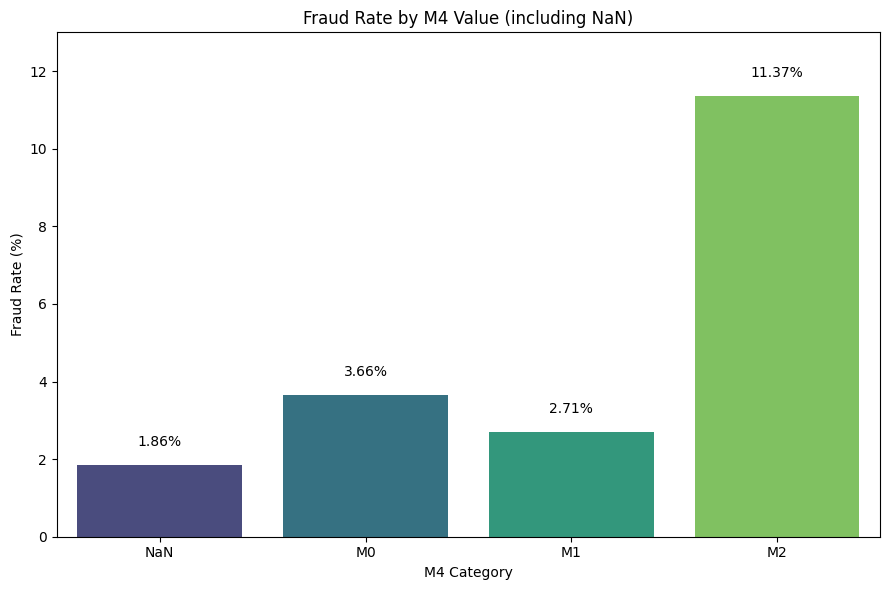

In [ ]:
# Compute fraud rate by M4 (including NaN)
m4_fraud = train_t_trimmed.groupby('M4', dropna=False)['isFraud'].mean().mul(100).round(2).reset_index()
m4_fraud.columns = ['M4', 'fraud_rate_%']

# Replace NaN with string 'NaN' for plotting
m4_fraud['M4'] = m4_fraud['M4'].fillna('NaN').astype(str)

# Bar plot
plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=m4_fraud,
    x='M4',
    y='fraud_rate_%',
    palette='viridis',
    order=['NaN', 'M0', 'M1', 'M2']
)

for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.4,                # offset above bar
        f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.ylim(0, 13)
plt.title('Fraud Rate by M4 Value (including NaN)')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('M4 Category')
plt.tight_layout()
plt.show()

In [ ]:
m_cols = ['M1', 'M2', 'M3', 'M5', 'M6', 'M7', 'M8', 'M9']

for col in m_cols:
    print(f"\nFraud summary for {col}:")
    summary = (
        train_t_trimmed.groupby(col, dropna=False)['isFraud']
        .agg(['count', 'mean'])
        .assign(fraud_pct = lambda x: (x['mean'] * 100).round(2))   # <-- changed to fraud_pct
        .rename_axis(col)
    )
    print(summary)


Fraud summary for M1:
      count  mean  fraud_pct
M1                          
F        25     0          0
T    319415     0          2
NaN  271100     0          5

Fraud summary for M2:
      count  mean  fraud_pct
M2                          
F     33972     0          3
T    285468     0          2
NaN  271100     0          5

Fraud summary for M3:
      count  mean  fraud_pct
M3                          
F     67709     0          3
T    251731     0          2
NaN  271100     0          5

Fraud summary for M5:
      count  mean  fraud_pct
M5                          
F    132491     0          3
T    107567     0          4
NaN  350482     0          4

Fraud summary for M6:
      count  mean  fraud_pct
M6                          
F    227856     0          2
T    193324     0          2
NaN  169360     0          7

Fraud summary for M7:
      count  mean  fraud_pct
M7                          
F    211374     0          2
T     32901     0          2
NaN  346265     0    

In [ ]:
# For standard M columns (T/F/NaN → 1 = T or F, 0 = NaN)
for col in ['M1', 'M2', 'M3', 'M5', 'M6', 'M7', 'M8', 'M9']:
    new_col = f'{col}_checked'
    train_t_trimmed[new_col] = train_t_trimmed[col].notna().astype(int)   # True/False → 1/0

# For M4 special mapping: 0 = M2 (strong match), 1 = M0/M1/NaN
train_t_trimmed['M4_checked'] = (train_t_trimmed['M4'] != 'M2').astype(int)
train_t_trimmed['M4_checked'] = train_t_trimmed['M4_checked'].fillna(1)  # NaN → 1 (not strong)

# Quick verification: show the new columns
print("New binary M flags added:")
print(train_t_trimmed.filter(like='_checked').head())
print("\nValue counts for one example (M6_checked):")
print(train_t_trimmed['M6_checked'].value_counts(dropna=False))

New binary M flags added:
   M1_checked  M2_checked  M3_checked  M5_checked  M6_checked  M7_checked  \
0           1           1           1           1           1           0   
1           0           0           0           1           1           0   
2           1           1           1           1           1           1   
3           0           0           0           1           1           0   
4           0           0           0           0           0           0   

   M8_checked  M9_checked  M4_checked  
0           0           0           0  
1           0           0           1  
2           1           1           1  
3           0           0           1  
4           0           0           1  

Value counts for one example (M6_checked):
M6_checked
1    421180
0    169360
Name: count, dtype: int64


In [ ]:
checked_cols = [col for col in train_t_trimmed.columns if col.endswith('_checked')]

for col in checked_cols:
    print(f"\nFraud rate by {col}:")
    print(train_t_trimmed.groupby(col)['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))


Fraud rate by M1_checked:
             count  mean  fraud_pct
M1_checked                         
0           271100     0          5
1           319440     0          2

Fraud rate by M2_checked:
             count  mean  fraud_pct
M2_checked                         
0           271100     0          5
1           319440     0          2

Fraud rate by M3_checked:
             count  mean  fraud_pct
M3_checked                         
0           271100     0          5
1           319440     0          2

Fraud rate by M5_checked:
             count  mean  fraud_pct
M5_checked                         
0           350482     0          4
1           240058     0          3

Fraud rate by M6_checked:
             count  mean  fraud_pct
M6_checked                         
0           169360     0          7
1           421180     0          2

Fraud rate by M7_checked:
             count  mean  fraud_pct
M7_checked                         
0           346265     0          5
1         

In [ ]:
# List of columns to drop:
# - All original raw M columns
# - All _checked flags except the 4 keepers
columns_to_drop = [
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',           # raw M columns
    'M2_checked', 'M3_checked', 'M5_checked', 'M7_checked', 'M9_checked'  # redundant _checked flags
]

# Drop them (errors='ignore' prevents crash if any are already missing)
train_t_trimmed = train_t_trimmed.drop(columns=columns_to_drop, errors='ignore')

# Quick check after dropping
print("Shape after dropping raw M columns and redundant flags:", train_t_trimmed.shape)
print("\nRemaining _checked flags:")
print(train_t_trimmed.filter(like='_checked').columns.tolist())

# Optional: rename for clarity (optional step)
train_t_trimmed = train_t_trimmed.rename(columns={
    'M1_checked': 'm1_checked',
    'M4_checked': 'm4_checked',
    'M6_checked': 'm6_checked',
    'M8_checked': 'm8_checked'
})

print("\nFirst few rows of remaining checked flags:")
print(train_t_trimmed.filter(like='_checked').head())

Shape after dropping raw M columns and redundant flags: (590540, 21)

Remaining _checked flags:
['M1_checked', 'M6_checked', 'M8_checked', 'M4_checked']

First few rows of remaining checked flags:
   m1_checked  m6_checked  m8_checked  m4_checked
0           1           1           0           0
1           0           1           0           1
2           1           1           1           1
3           0           1           0           1
4           0           0           0           1


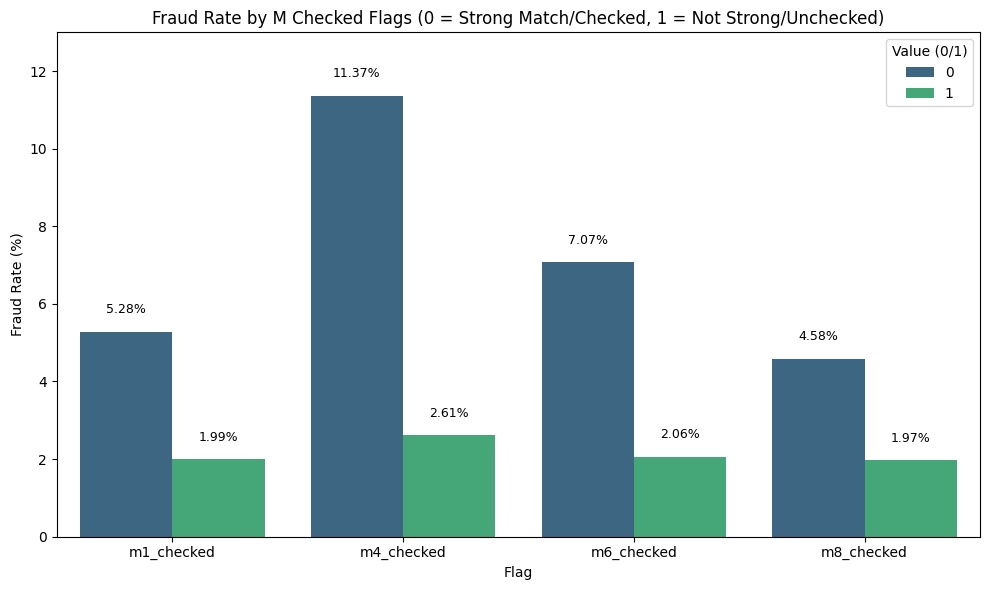

In [ ]:
# List of your kept flags
checked_cols = ['m1_checked', 'm4_checked', 'm6_checked', 'm8_checked']

# Compute fraud rates for each flag
fraud_rates = []
for col in checked_cols:
    rates = train_t_trimmed.groupby(col)['isFraud'].mean().mul(100).round(2)
    for val, rate in rates.items():
        fraud_rates.append({'Flag': col, 'Value': val, 'Fraud Rate %': rate})

df_plot = pd.DataFrame(fraud_rates)

# Bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_plot,
    x='Flag',
    y='Fraud Rate %',
    hue='Value',
    palette='viridis'
)

# Add labels using the manual method that worked before
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    if height > 0:  # avoid labeling zero-height if any
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.4,
            f'{height:.2f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.title('Fraud Rate by M Checked Flags (0 = Strong Match/Checked, 1 = Not Strong/Unchecked)')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Flag')
plt.ylim(0, 13)  # headroom
plt.legend(title='Value (0/1)')
plt.tight_layout()
plt.show()

In [ ]:
# Create binary presence flags
train_t_trimmed['addr1_present'] = train_t_trimmed['addr1'].notnull().astype(int)
train_t_trimmed['addr2_present'] = train_t_trimmed['addr2'].notnull().astype(int)

# Fraud rate by addr1 presence
print("Fraud rate by addr1_present:")
print(train_t_trimmed.groupby('addr1_present')['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))

# Fraud rate by addr2 presence
print("\nFraud rate by addr2_present:")
print(train_t_trimmed.groupby('addr2_present')['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))

Fraud rate by addr1_present:
                count  mean  fraud_pct
addr1_present                         
0               65706     0         12
1              524834     0          2

Fraud rate by addr2_present:
                count  mean  fraud_pct
addr2_present                         
0               65706     0         12
1              524834     0          2


In [ ]:
train_t_trimmed.filter(like='addr').head(10)

,addr1,addr2,addr1_present,addr2_present
0,315,87,1,1
1,325,87,1,1
2,330,87,1,1
3,476,87,1,1
4,420,87,1,1
5,272,87,1,1
6,126,87,1,1
7,325,87,1,1
8,337,87,1,1
9,204,87,1,1


In [ ]:
print("Describe for addr1:")
print(train_t_trimmed['addr1'].describe().round(2))

print("\nDescribe for addr2:")
print(train_t_trimmed['addr2'].describe().round(2))

Describe for addr1:
count   524,834
mean        291
std         102
min         100
25%         204
50%         299
75%         330
max         540
Name: addr1, dtype: float64

Describe for addr2:
count   524,834
mean         87
std           3
min          10
25%          87
50%          87
75%          87
max         102
Name: addr2, dtype: float64


In [ ]:
bins = [99, 199, 299, 399, 540]
labels = ['100-199', '200-299', '300-399', '400-540']

train_t_trimmed['addr1_bin'] = pd.cut(
    train_t_trimmed['addr1'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

fraud_by_bin = train_t_trimmed.groupby('addr1_bin', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_by_bin['fraud_pct'] = (fraud_by_bin['mean'] * 100).round(2)
print(fraud_by_bin.sort_index())

            count  mean  fraud_pct
addr1_bin                         
100-199    101112     0          2
200-299    194975     0          2
300-399    139644     0          3
400-540     89103     0          3


In [ ]:
# Drop raw addr1 and addr2
train_t_trimmed = train_t_trimmed.drop(columns=['addr1', 'addr2'], errors='ignore')

# Drop the redundant second presence flag (keep addr1_present)
train_t_trimmed = train_t_trimmed.drop(columns=['addr2_present'], errors='ignore')

# Quick check
print("Shape after cleanup:", train_t_trimmed.shape)
print("\nRemaining addr-related column:", 'addr1_present' in train_t_trimmed.columns)

Shape after cleanup: (590540, 21)

Remaining addr-related column: True


In [ ]:
train_t_trimmed = train_t_trimmed.drop(columns=['addr1_bin'], errors='ignore')

/tmp/ipython-input-232/3620698475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


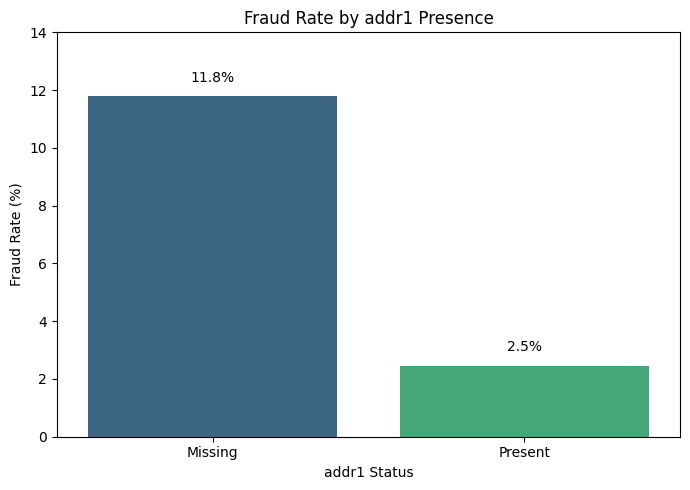

In [ ]:
# Compute fraud rates
rates = train_t_trimmed.groupby('addr1_present')['isFraud'].mean().mul(100).round(2).reset_index()
rates.columns = ['addr1_present', 'fraud_rate_%']
rates['addr1_present'] = rates['addr1_present'].map({0: 'Missing', 1: 'Present'})

# Bar plot
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=rates,
    x='addr1_present',
    y='fraud_rate_%',
    palette='viridis'
)

# Manual labels (worked for you before)
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.4,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Fraud Rate by addr1 Presence')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('addr1 Status')
plt.ylim(0, 14)  # headroom
plt.tight_layout()
plt.show()

In [ ]:
train_t_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   TransactionID   590540 non-null  int64  
 1   isFraud         590540 non-null  int64  
 2   TransactionDT   590540 non-null  int64  
 3   TransactionAmt  590540 non-null  float64
 4   ProductCD       590540 non-null  object 
 5   card1           590540 non-null  int64  
 6   card2           581607 non-null  float64
 7   card3           588975 non-null  float64
 8   card4           588963 non-null  object 
 9   card5           586281 non-null  float64
 10  card6           588969 non-null  object 
 11  P_emaildomain   496084 non-null  object 
 12  R_emaildomain   137291 non-null  object 
 13  has_dist2       590540 non-null  int64  
 14  has_dist1       590540 non-null  int64  
 15  m1_checked      590540 non-null  int64  
 16  m6_checked      590540 non-null  int64  
 17  m8_checked

In [ ]:
print("\nP_emaildomain:")
print("Unique non-null values:", train_t_trimmed['P_emaildomain'].nunique())
print("Missing (NaN) rows:", train_t_trimmed['P_emaildomain'].isna().sum())
print("Total rows:", len(train_t_trimmed))

print("\nR_emaildomain:")
print("Unique non-null values:", train_t_trimmed['R_emaildomain'].nunique())
print("Missing (NaN) rows:", train_t_trimmed['R_emaildomain'].isna().sum())
print("Total rows:", len(train_t_trimmed))


P_emaildomain:
Unique non-null values: 59
Missing (NaN) rows: 94456
Total rows: 590540

R_emaildomain:
Unique non-null values: 60
Missing (NaN) rows: 453249
Total rows: 590540


In [ ]:
print("Fraud rate by P_emaildomain present (1) vs missing (0):")
print(train_t_trimmed.groupby(train_t_trimmed['P_emaildomain'].notnull())['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))

Fraud rate by P_emaildomain present (1) vs missing (0):
                count  mean  fraud_pct
P_emaildomain                         
False           94456     0          3
True           496084     0          4


In [ ]:
print("\nFraud rate by R_emaildomain present (1) vs missing (0):")
print(train_t_trimmed.groupby(train_t_trimmed['R_emaildomain'].notnull())['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))


Fraud rate by R_emaildomain present (1) vs missing (0):
                count  mean  fraud_pct
R_emaildomain                         
False          453249     0          2
True           137291     0          8


In [ ]:
# Create binary flag for R_emaildomain
train_t_trimmed['r_email_present'] = train_t_trimmed['R_emaildomain'].notnull().astype(int)

# Drop raw R_emaildomain
train_t_trimmed = train_t_trimmed.drop(columns=['R_emaildomain'], errors='ignore')

# Quick fraud rate check on the new flag
print("Fraud rate by r_email_present:")
print(train_t_trimmed.groupby('r_email_present')['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))

Fraud rate by r_email_present:
                  count  mean  fraud_pct
r_email_present                         
0                453249     0          2
1                137291     0          8


In [ ]:
# Top 10 P_emaildomain by percentage (of total rows, including missing)
email_perc = train_t_trimmed['P_emaildomain'].value_counts(normalize=True).head(10) * 100
email_perc = email_perc.round(2)

# Add missing as a category for completeness
missing_perc = (train_t_trimmed['P_emaildomain'].isna().sum() / len(train_t_trimmed)) * 100
print("Missing (NaN):", round(missing_perc, 2), "%\n")

print("Top 10 P_emaildomain by percentage:")
print(email_perc.astype(str) + " %")

Missing (NaN): 15.99 %

Top 10 P_emaildomain by percentage:
P_emaildomain
gmail.com        46.03 %
yahoo.com        20.35 %
hotmail.com       9.12 %
anonymous.com     7.46 %
aol.com            5.7 %
comcast.net       1.59 %
icloud.com        1.26 %
outlook.com       1.03 %
msn.com           0.82 %
att.net           0.81 %
Name: proportion, dtype: object


In [ ]:
# Top 8 domains
top8 = train_t_trimmed['P_emaildomain'].value_counts().head(8).index.tolist()

# Create grouped column
train_t_trimmed['P_email_grouped'] = train_t_trimmed['P_emaildomain'].apply(
    lambda x: x if x in top8 else ('Missing' if pd.isna(x) else 'Other')
)

# Then get percentages
print(train_t_trimmed['P_email_grouped'].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")

P_email_grouped
gmail.com        38.67 %
yahoo.com        17.09 %
Missing          15.99 %
hotmail.com       7.66 %
Other             6.27 %
anonymous.com     6.27 %
aol.com           4.79 %
comcast.net       1.34 %
icloud.com        1.06 %
outlook.com       0.86 %
Name: proportion, dtype: object


In [ ]:
# Fraud rate by grouped email domain
fraud_by_group = train_t_trimmed.groupby('P_email_grouped')['isFraud'].agg(['count', 'mean'])
fraud_by_group['fraud_pct'] = (fraud_by_group['mean'] * 100).round(2)
fraud_by_group = fraud_by_group.sort_values('fraud_pct', ascending=False)

print("Fraud rate by P_email_grouped (sorted by highest fraud %):")
print(fraud_by_group[['count', 'fraud_pct']])

Fraud rate by P_email_grouped (sorted by highest fraud %):
                  count  fraud_pct
P_email_grouped                   
outlook.com        5096          9
hotmail.com       45250          5
gmail.com        228355          4
icloud.com         6267          3
comcast.net        7888          3
Missing           94456          3
anonymous.com     36998          2
yahoo.com        100934          2
Other             37007          2
aol.com           28289          2


In [ ]:
# Define the categories to keep separate
keep_separate = ['gmail.com', 'hotmail.com', 'outlook.com']

# Create the new grouped column
train_t_trimmed['P_email_grouped_v2'] = train_t_trimmed['P_emaildomain'].apply(
    lambda x: x if x in keep_separate else ('Missing' if pd.isna(x) else 'Other')
)

# Verify the new distribution (percentages sum to 100%)
print("Updated P_email_grouped_v2 distribution:")
print(train_t_trimmed['P_email_grouped_v2'].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")

Updated P_email_grouped_v2 distribution:
P_email_grouped_v2
gmail.com      38.67 %
Other          36.81 %
Missing        15.99 %
hotmail.com     7.66 %
outlook.com     0.86 %
Name: proportion, dtype: object


In [ ]:
fraud_by_group_v2 = train_t_trimmed.groupby('P_email_grouped_v2')['isFraud'].agg(['count', 'mean'])
fraud_by_group_v2['fraud_pct'] = (fraud_by_group_v2['mean'] * 100).round(2)
fraud_by_group_v2 = fraud_by_group_v2.sort_values('fraud_pct', ascending=False)

print("Fraud rate by P_email_grouped_v2 (sorted by highest fraud %):")
print(fraud_by_group_v2[['count', 'fraud_pct']])

Fraud rate by P_email_grouped_v2 (sorted by highest fraud %):
                     count  fraud_pct
P_email_grouped_v2                   
outlook.com           5096          9
hotmail.com          45250          5
gmail.com           228355          4
Missing              94456          3
Other               217383          2


In [ ]:
train_t_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TransactionID       590540 non-null  int64  
 1   isFraud             590540 non-null  int64  
 2   TransactionDT       590540 non-null  int64  
 3   TransactionAmt      590540 non-null  float64
 4   ProductCD           590540 non-null  object 
 5   card1               590540 non-null  int64  
 6   card2               581607 non-null  float64
 7   card3               588975 non-null  float64
 8   card4               588963 non-null  object 
 9   card5               586281 non-null  float64
 10  card6               588969 non-null  object 
 11  P_emaildomain       496084 non-null  object 
 12  has_dist2           590540 non-null  int64  
 13  has_dist1           590540 non-null  int64  
 14  m1_checked          590540 non-null  int64  
 15  m6_checked          590540 non-nul

In [ ]:
# Drop the raw and old grouped versions
train_t_trimmed = train_t_trimmed.drop(columns=['P_emaildomain', 'P_email_grouped'], errors='ignore')

# Confirm only the v2 version remains
print("Remaining email-related columns:", [col for col in train_t_trimmed.columns if 'email' in col.lower()])
print("\nValue counts in P_email_grouped_v2 (should sum to 590,540):")
print(train_t_trimmed['P_email_grouped_v2'].value_counts())

Remaining email-related columns: ['r_email_present', 'P_email_grouped_v2']

Value counts in P_email_grouped_v2 (should sum to 590,540):
P_email_grouped_v2
gmail.com      228355
Other          217383
Missing         94456
hotmail.com     45250
outlook.com      5096
Name: count, dtype: int64


In [ ]:
train_t_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TransactionID       590540 non-null  int64  
 1   isFraud             590540 non-null  int64  
 2   TransactionDT       590540 non-null  int64  
 3   TransactionAmt      590540 non-null  float64
 4   ProductCD           590540 non-null  object 
 5   card1               590540 non-null  int64  
 6   card2               581607 non-null  float64
 7   card3               588975 non-null  float64
 8   card4               588963 non-null  object 
 9   card5               586281 non-null  float64
 10  card6               588969 non-null  object 
 11  has_dist2           590540 non-null  int64  
 12  has_dist1           590540 non-null  int64  
 13  m1_checked          590540 non-null  int64  
 14  m6_checked          590540 non-null  int64  
 15  m8_checked          590540 non-nul

In [ ]:
print("First 5 rows of card1 to card6:")
print(train_t_trimmed[['card1', 'card2', 'card3', 'card4', 'card5', 'card6']].head())

First 5 rows of card1 to card6:
   card1  card2  card3       card4  card5   card6
0  13926    NaN    150    discover    142  credit
1   2755    404    150  mastercard    102  credit
2   4663    490    150        visa    166   debit
3  18132    567    150  mastercard    117   debit
4   4497    514    150  mastercard    102  credit


In [ ]:
card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

for col in card_cols:
    unique_count = train_t_trimmed[col].nunique()
    missing_count = train_t_trimmed[col].isna().sum()
    print(f"{col}: {unique_count} unique values | {missing_count} missing")

card1: 13553 unique values | 0 missing
card2: 500 unique values | 8933 missing
card3: 114 unique values | 1565 missing
card4: 4 unique values | 1577 missing
card5: 119 unique values | 4259 missing
card6: 4 unique values | 1571 missing


In [ ]:
# Fraud rate by card4 (brand)
print("Fraud rate by card4:")
print(train_t_trimmed.groupby('card4', dropna=False)['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))

# Fraud rate by card6 (type)
print("\nFraud rate by card6:")
print(train_t_trimmed.groupby('card6', dropna=False)['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))

Fraud rate by card4:
                   count  mean  fraud_pct
card4                                    
american express    8328     0          3
discover            6651     0          8
mastercard        189217     0          3
visa              384767     0          3
NaN                 1577     0          3

Fraud rate by card6:
                  count  mean  fraud_pct
card6                                   
charge card          15     0          0
credit           148986     0          7
debit            439938     0          2
debit or credit      30     0          0
NaN                1571     0          2


In [ ]:
card_numeric = ['card1', 'card2', 'card3', 'card5']

for col in card_numeric:
    print(f"\nDescribe for {col}:")
    print(train_t_trimmed[col].describe().round(2))


Describe for card1:
count   590,540
mean      9,899
std       4,901
min       1,000
25%       6,019
50%       9,678
75%      14,184
max      18,396
Name: card1, dtype: float64

Describe for card2:
count   581,607
mean        363
std         158
min         100
25%         214
50%         361
75%         512
max         600
Name: card2, dtype: float64

Describe for card3:
count   588,975
mean        153
std          11
min         100
25%         150
50%         150
75%         150
max         231
Name: card3, dtype: float64

Describe for card5:
count   586,281
mean        199
std          41
min         100
25%         166
50%         226
75%         226
max         237
Name: card5, dtype: float64


In [ ]:
# Define bins based on quartiles + a bit of rounding
bins = [999, 6000, 10000, 14000, 18400]
labels = ['1000-5999', '6000-9999', '10000-13999', '14000-18396']

# Create temporary bin column
train_t_trimmed['card1_bin'] = pd.cut(
    train_t_trimmed['card1'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Fraud rate by bin
fraud_by_card1_bin = train_t_trimmed.groupby('card1_bin', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_by_card1_bin['fraud_pct'] = (fraud_by_card1_bin['mean'] * 100).round(2)

print("Fraud rate by card1 bin (non-null only):")
print(fraud_by_card1_bin.sort_index())

Fraud rate by card1 bin (non-null only):
              count  mean  fraud_pct
card1_bin                           
1000-5999    144089     0          4
6000-9999    159127     0          4
10000-13999  134729     0          3
14000-18396  152595     0          3


In [ ]:
bins = [99, 199, 299, 399, 499, 599]
labels = ['100-199', '200-299', '300-399', '400-499', '500-599']

train_t_trimmed['card2_bin'] = pd.cut(
    train_t_trimmed['card2'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

fraud_by_card2_bin = train_t_trimmed.groupby('card2_bin', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_by_card2_bin['fraud_pct'] = (fraud_by_card2_bin['mean'] * 100).round(2)

print("Fraud rate by card2 bin (non-null only):")
print(fraud_by_card2_bin.sort_index())

Fraud rate by card2 bin (non-null only):
            count  mean  fraud_pct
card2_bin                         
100-199    135148     0          4
200-299     66038     0          3
300-399    122055     0          3
400-499    100319     0          3
500-599    157853     0          4


In [ ]:
bins = [99, 149, 150, 159, 199, 231]
labels = ['100-149', '150', '151-159', '160-199', '200-231']

train_t_trimmed['card3_bin'] = pd.cut(
    train_t_trimmed['card3'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

fraud_by_card3_bin = train_t_trimmed.groupby('card3_bin', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_by_card3_bin['fraud_pct'] = (fraud_by_card3_bin['mean'] * 100).round(2)

print("Fraud rate by card3 bin (non-null only):")
print(fraud_by_card3_bin.sort_index())

Fraud rate by card3 bin (non-null only):
            count  mean  fraud_pct
card3_bin                         
100-149      8950     0          4
150        521287     0          2
151-159       119     0          3
160-199     57379     0         13
200-231      1240     0          3


In [ ]:
bins = [99, 165, 199, 225, 237]
labels = ['100-165', '166-199', '200-225', '226-237']

train_t_trimmed['card5_bin'] = pd.cut(
    train_t_trimmed['card5'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

fraud_by_card5_bin = train_t_trimmed.groupby('card5_bin', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_by_card5_bin['fraud_pct'] = (fraud_by_card5_bin['mean'] * 100).round(2)

print("Fraud rate by card5 bin (non-null only):")
print(fraud_by_card5_bin.sort_index())

Fraud rate by card5 bin (non-null only):
            count  mean  fraud_pct
card5_bin                         
100-165    108082     0          6
166-199     78291     0          2
200-225    100269     0          4
226-237    299639     0          3


In [ ]:
train_t_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   TransactionID       590540 non-null  int64   
 1   isFraud             590540 non-null  int64   
 2   TransactionDT       590540 non-null  int64   
 3   TransactionAmt      590540 non-null  float64 
 4   ProductCD           590540 non-null  object  
 5   card4               588963 non-null  object  
 6   card6               588969 non-null  object  
 7   has_dist2           590540 non-null  int64   
 8   has_dist1           590540 non-null  int64   
 9   m1_checked          590540 non-null  int64   
 10  m6_checked          590540 non-null  int64   
 11  m8_checked          590540 non-null  int64   
 12  m4_checked          590540 non-null  int64   
 13  addr1_present       590540 non-null  int64   
 14  r_email_present     590540 non-null  int64   
 15  P_email_grouped_v

In [ ]:
# Columns to drop
drop_cols = [
    'card1', 'card2', 'card3', 'card5',          # raw numeric
    'card1_bin', 'card2_bin'                     # temporary bins
]

train_t_trimmed = train_t_trimmed.drop(columns=drop_cols, errors='ignore')

# Verify what's left for card*
print("Remaining card-related columns:")
print([col for col in train_t_trimmed.columns if 'card' in col.lower()])

Remaining card-related columns:
['card4', 'card6', 'card3_bin', 'card5_bin']


In [ ]:
print("Unique values and counts in ProductCD (including NaN if any):")
print(train_t_trimmed['ProductCD'].value_counts(dropna=False))

Unique values and counts in ProductCD (including NaN if any):
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64


In [ ]:
fraud_by_product = train_t_trimmed.groupby('ProductCD', dropna=False)['isFraud'].agg(['count', 'mean'])
fraud_by_product['fraud_pct'] = (fraud_by_product['mean'] * 100).round(2)
fraud_by_product = fraud_by_product.sort_values('fraud_pct', ascending=False)

print("Fraud rate by ProductCD (sorted by highest fraud %):")
print(fraud_by_product[['count', 'fraud_pct']])

Fraud rate by ProductCD (sorted by highest fraud %):
            count  fraud_pct
ProductCD                   
C           68519         12
S           11628          6
H           33024          5
R           37699          4
W          439670          2


In [ ]:
print(train_t_trimmed['TransactionDT'].tail(10))

590530    15810926
590531    15810935
590532    15811007
590533    15811029
590534    15811030
590535    15811047
590536    15811049
590537    15811079
590538    15811088
590539    15811131
Name: TransactionDT, dtype: int64


In [ ]:
train_t_trimmed['TransactionDT'].describe()

,TransactionDT
count,"590,540"
mean,"7,372,311"
std,"4,617,224"
min,"86,400"
25%,"3,027,058"
50%,"7,306,528"
75%,"11,246,620"
max,"15,811,131"


In [ ]:
# Create hour of day (0–23) and day of week (0–6)
train_t_trimmed['hour'] = (train_t_trimmed['TransactionDT'] % 86400) // 3600
train_t_trimmed['day_of_week'] = (train_t_trimmed['TransactionDT'] // 86400) % 7

# Fraud rate by hour of day
print("Fraud rate by hour of day (0–23):")
hour_fraud = train_t_trimmed.groupby('hour')['isFraud'].agg(['count', 'mean'])
hour_fraud['fraud_pct'] = (hour_fraud['mean'] * 100).round(2)
print(hour_fraud[['count', 'fraud_pct']])

# Fraud rate by day of week (0–6)
print("\nFraud rate by day of week (0–6):")
dow_fraud = train_t_trimmed.groupby('day_of_week')['isFraud'].agg(['count', 'mean'])
dow_fraud['fraud_pct'] = (dow_fraud['mean'] * 100).round(2)
print(dow_fraud[['count', 'fraud_pct']])

Fraud rate by hour of day (0–23):
      count  fraud_pct
hour                  
0     37795          3
1     32797          3
2     26732          4
3     20802          4
4     14839          5
5      9701          7
6      6007          8
7      3704         11
8      2591          9
9      2479          9
10     3627          5
11     6827          4
12    12451          3
13    20315          2
14    28328          2
15    33859          3
16    38698          3
17    40723          3
18    41639          4
19    42115          3
20    41782          3
21    41641          3
22    41139          3
23    39949          4

Fraud rate by day of week (0–6):
             count  fraud_pct
day_of_week                  
0            86377          4
1            98502          4
2            79834          4
3            70223          4
4            85433          3
5            84815          3
6            85356          3


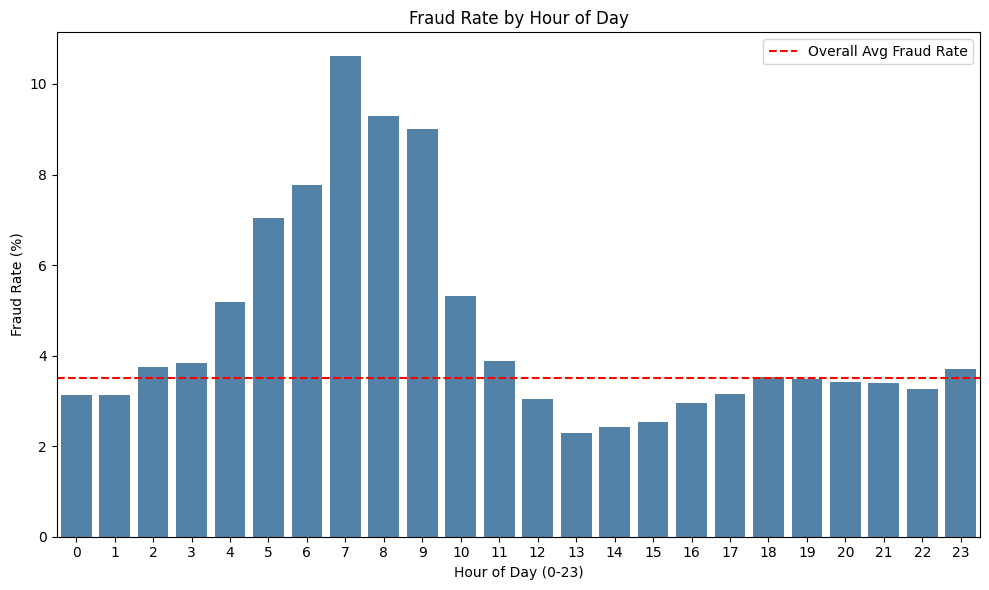

In [ ]:
# Fraud rate by hour
hour_fraud = train_t_trimmed.groupby('hour')['isFraud'].agg(['count', 'mean'])
hour_fraud['fraud_pct'] = hour_fraud['mean'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=hour_fraud.index, y=hour_fraud['fraud_pct'], color='steelblue')
plt.axhline(y=train_t_trimmed['isFraud'].mean()*100, color='red', linestyle='--', label='Overall Avg Fraud Rate')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

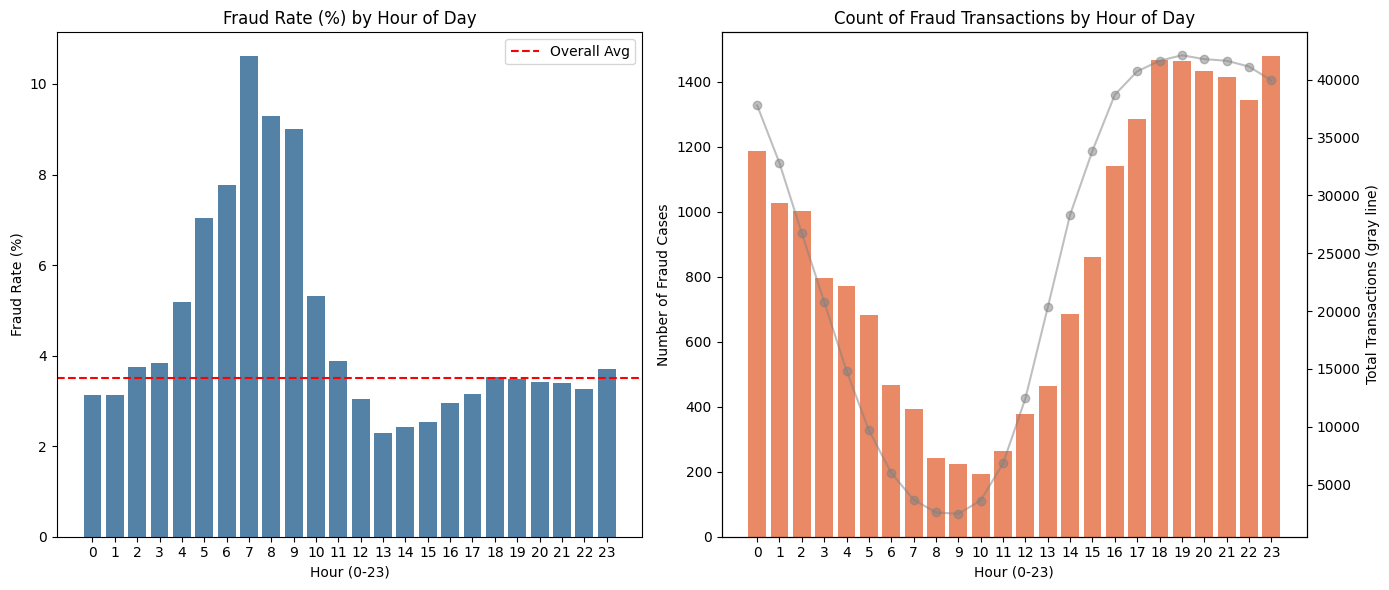

In [ ]:
# Aggregate: count of transactions, fraud count, fraud rate
hour_stats = train_t_trimmed.groupby('hour')['isFraud'].agg(
    total_count='count',
    fraud_count='sum',
    fraud_rate='mean'
)
hour_stats['fraud_pct'] = hour_stats['fraud_rate'] * 100
hour_stats = hour_stats.reset_index()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Plot 1: Fraud Rate (%)
sns.barplot(data=hour_stats, x='hour', y='fraud_pct', ax=ax1, color='steelblue')
ax1.set_title('Fraud Rate (%) by Hour of Day')
ax1.set_xlabel('Hour (0-23)')
ax1.set_ylabel('Fraud Rate (%)')
ax1.axhline(y=train_t_trimmed['isFraud'].mean()*100, color='red', linestyle='--', label='Overall Avg')
ax1.legend()

# Plot 2: Fraud Count (absolute)
sns.barplot(data=hour_stats, x='hour', y='fraud_count', ax=ax2, color='coral')
ax2.set_title('Count of Fraud Transactions by Hour of Day')
ax2.set_xlabel('Hour (0-23)')
ax2.set_ylabel('Number of Fraud Cases')

# Optional: add total transactions on secondary y-axis for context (comment out if not needed)
ax2_twin = ax2.twinx()
ax2_twin.plot(hour_stats['hour'], hour_stats['total_count'], color='gray', linestyle='-', marker='o', alpha=0.5)
ax2_twin.set_ylabel('Total Transactions (gray line)')

plt.tight_layout()
plt.show()

In [ ]:
train_t_trimmed = train_t_trimmed.drop(columns=['month', 'days_since_start', 'day_of_week', 'TransactionDT'], errors='ignore')

In [ ]:
train_t_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   TransactionID       590540 non-null  int64   
 1   isFraud             590540 non-null  int64   
 2   TransactionAmt      590540 non-null  float64 
 3   ProductCD           590540 non-null  object  
 4   card4               588963 non-null  object  
 5   card6               588969 non-null  object  
 6   has_dist2           590540 non-null  int64   
 7   has_dist1           590540 non-null  int64   
 8   m1_checked          590540 non-null  int64   
 9   m6_checked          590540 non-null  int64   
 10  m8_checked          590540 non-null  int64   
 11  m4_checked          590540 non-null  int64   
 12  addr1_present       590540 non-null  int64   
 13  r_email_present     590540 non-null  int64   
 14  P_email_grouped_v2  590540 non-null  object  
 15  card3_bin        

In [ ]:
train_t_trimmed['TransactionAmt'].describe()

,TransactionAmt
count,"590,540"
mean,135
std,239
min,0
25%,43
50%,69
75%,125
max,"31,937"


In [ ]:
# Define bins for TransactionAmt
bins = [0, 50, 100, 200, 500, 1000, 5000, float('inf')]
labels = ['0-50', '50-100', '100-200', '200-500', '500-1000', '1000-5000', '5000+']

train_t_trimmed['amt_bin'] = pd.cut(
    train_t_trimmed['TransactionAmt'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# Fraud rate by amt bin
fraud_by_amt_bin = train_t_trimmed.groupby('amt_bin', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_by_amt_bin['fraud_pct'] = (fraud_by_amt_bin['mean'] * 100).round(2)

print("Fraud rate by TransactionAmt bin:")
print(fraud_by_amt_bin.sort_index())

Fraud rate by TransactionAmt bin:
            count  mean  fraud_pct
amt_bin                           
0-50       187515     0          4
50-100     160742     0          3
100-200    141813     0          3
200-500     76146     0          4
500-1000    16744     0          6
1000-5000    7562     0          2
5000+          18     0          6


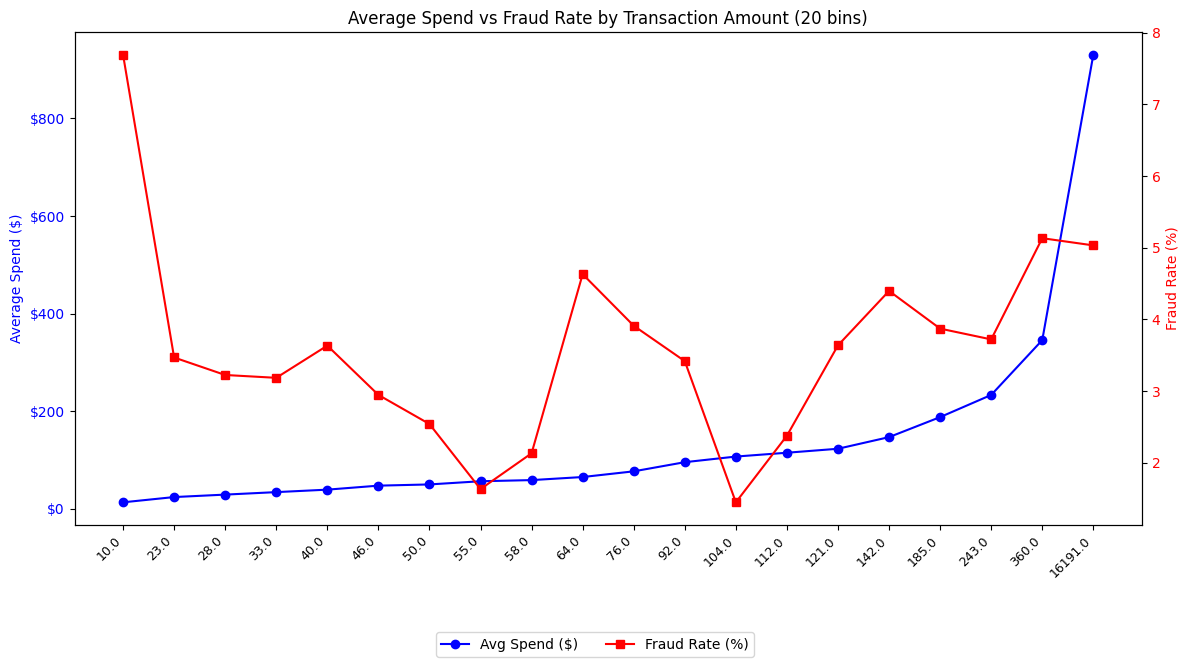

In [ ]:
# Create 20 equal-width bins for TransactionAmt
bins = pd.qcut(train_t_trimmed['TransactionAmt'], q=20, duplicates='drop')
bin_centers = bins.cat.categories.mid  # approximate center of each bin

# Aggregate per bin
stats = train_t_trimmed.groupby(bins, observed=True).agg(
    spend=('TransactionAmt', 'mean'),
    fraud_rate=('isFraud', 'mean'),
    count=('isFraud', 'count')
)

# Convert fraud_rate to percentage
stats['fraud_pct'] = stats['fraud_rate'] * 100

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Avg Spend (rounded labels)
ax1.plot(range(len(stats)), stats['spend'], color='blue', marker='o', label='Avg Spend ($)')
ax1.set_ylabel('Average Spend ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}' if x >= 0 else f'-${int(abs(x)):,}'))

# Fraud Rate
ax2 = ax1.twinx()
ax2.plot(range(len(stats)), stats['fraud_pct'], color='red', marker='s', label='Fraud Rate (%)')
ax2.set_ylabel('Fraud Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Clean x-axis (your previous fix)
bin_labels = [str(b.mid.round(0)) if isinstance(b, pd.Interval) else str(b) for b in stats.index]
ax1.set_xticks(range(len(stats)))
ax1.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=9)

plt.title('Average Spend vs Fraud Rate by Transaction Amount (20 bins)')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.tight_layout()
plt.show()

In [ ]:
# In the original train_t_df
train_t_df['card_key'] = (
    train_t_df['card1'].astype(str) + '_' +
    train_t_df['card2'].astype(str).fillna('nan') + '_' +
    train_t_df['card3'].astype(str).fillna('nan') + '_' +
    train_t_df['card4'].fillna('nan') + '_' +
    train_t_df['card5'].astype(str).fillna('nan') + '_' +
    train_t_df['card6'].fillna('nan')
)

In [ ]:
print("Unique card_keys:", train_t_df['card_key'].nunique())
print("\nTop 10 most frequent card_keys (and their transaction counts):")
print(train_t_df['card_key'].value_counts().head(10))

print("\nMissing card_key count:", train_t_df['card_key'].isna().sum())
print("Total rows:", len(train_t_df))

Unique card_keys: 14893

Top 10 most frequent card_keys (and their transaction counts):
card_key
9500_321.0_150.0_visa_226.0_debit            14112
15885_545.0_185.0_visa_138.0_debit           10332
17188_321.0_150.0_visa_226.0_debit           10312
7919_194.0_150.0_mastercard_166.0_debit       8844
15066_170.0_150.0_mastercard_102.0_credit     7918
12695_490.0_150.0_visa_226.0_debit            7079
6019_583.0_150.0_visa_226.0_credit            6766
12544_321.0_150.0_visa_226.0_debit            6760
2803_100.0_150.0_visa_226.0_debit             6126
7919_194.0_150.0_mastercard_202.0_debit       6047
Name: count, dtype: int64

Missing card_key count: 0
Total rows: 590540


In [ ]:
card_freq = train_t_df.groupby('card_key').size().reset_index(name='card_frequency')

In [ ]:
card_freq.describe()

,card_frequency
count,"14,893"
mean,40
std,298
min,1
25%,1
50%,4
75%,12
max,"14,112"


In [ ]:
# Merge frequency back to train_t_trimmed using TransactionID
train_t_trimmed = train_t_trimmed.merge(
    train_t_df[['TransactionID', 'card_key']],
    on='TransactionID',
    how='left'
).merge(
    card_freq,
    on='card_key',
    how='left'
)


In [ ]:
# Define bins for card_frequency
bins = [0, 1, 5, 10, 50, 100, 500, float('inf')]
labels = ['1', '2-5', '6-10', '11-50', '51-100', '101-500', '501+']

train_t_trimmed['freq_bin'] = pd.cut(
    train_t_trimmed['card_frequency'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Fraud rate by frequency bin
fraud_by_freq = train_t_trimmed.groupby('freq_bin', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_by_freq['fraud_pct'] = (fraud_by_freq['mean'] * 100).round(2)

print("Fraud rate by card_frequency bin (sorted by bin order):")
print(fraud_by_freq.sort_index())

Fraud rate by card_frequency bin (sorted by bin order):
           count  mean  fraud_pct
freq_bin                         
1           4103     0          4
2-5        14238     0          3
6-10       14923     0          3
11-50      65971     0          3
51-100     37433     0          3
101-500   113613     0          4
501+      340259     0          4


In [ ]:
# Define the bins with your new tail split
bins = [0, 500, 1000, 5000, 10000, float('inf')]
labels = ['1-500', '501-1000', '1001-5000', '5001-10000', '>10000']

train_t_trimmed['freq_bin_large_tail'] = pd.cut(
    train_t_trimmed['card_frequency'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Fraud rate by the new split bins
fraud_by_freq_large_tail = train_t_trimmed.groupby('freq_bin_large_tail', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_by_freq_large_tail['fraud_pct'] = (fraud_by_freq_large_tail['mean'] * 100).round(2)

print("Fraud rate by card_frequency large tail bins:")
print(fraud_by_freq_large_tail.sort_index())

Fraud rate by card_frequency large tail bins:
                      count  mean  fraud_pct
freq_bin_large_tail                         
1-500                250281     0          3
501-1000              69402     0          5
1001-5000            170971     0          4
5001-10000            65130     0          3
>10000                34756     0          4


In [ ]:
# Step 1: Create card_key if not already present
if 'card_key' not in train_t_df.columns:
    train_t_df['card_key'] = (
        train_t_df['card1'].astype(str) + '_' +
        train_t_df['card2'].astype(str).fillna('nan') + '_' +
        train_t_df['card3'].astype(str).fillna('nan') + '_' +
        train_t_df['card4'].fillna('nan') + '_' +
        train_t_df['card5'].astype(str).fillna('nan') + '_' +
        train_t_df['card6'].fillna('nan')
    )

# Step 2: Derive hour from TransactionDT
train_t_df['hour'] = (train_t_df['TransactionDT'] % 86400) // 3600

# Step 3: Group by card_key + hour and count transactions per group
velocity = train_t_df.groupby(['card_key', 'hour']).size().reset_index(name='transactions_per_hour')

# Step 4: Merge velocity back to original df using card_key + hour
train_t_df = train_t_df.merge(
    velocity,
    on=['card_key', 'hour'],
    how='left'
)

# (Optional) Quick check on the new column
print("transactions_per_hour summary:")
print(train_t_df['transactions_per_hour'].describe().round(2))

print("\nTop values:")
print(train_t_df['transactions_per_hour'].value_counts().head(10))

transactions_per_hour summary:
count   590,540
mean        134
std         203
min           1
25%           8
50%          43
75%         167
max       1,049
Name: transactions_per_hour, dtype: float64

Top values:
transactions_per_hour
1     40609
2     28902
3     22677
4     17464
5     14445
6     11772
7     10150
8      8872
9      7866
10     7020
Name: count, dtype: int64


In [ ]:
# Merge the new column into train_t_trimmed using TransactionID
train_t_trimmed = train_t_trimmed.merge(
    train_t_df[['TransactionID', 'transactions_per_hour']],
    on='TransactionID',
    how='left'
)

# Fill any rare missing (should be none)
train_t_trimmed['transactions_per_hour'] = train_t_trimmed['transactions_per_hour'].fillna(1).astype(int)

print("transactions_per_hour added to trimmed df. Summary:")
print(train_t_trimmed['transactions_per_hour'].describe().round(2))

transactions_per_hour added to trimmed df. Summary:
count   590,540
mean        134
std         203
min           1
25%           8
50%          43
75%         167
max       1,049
Name: transactions_per_hour, dtype: float64


In [ ]:
# Define bins for transactions_per_hour
bins = [0, 10, 50, 100, 200, 500, float('inf')]
labels = ['1-10', '11-50', '51-100', '101-200', '201-500', '>500']

train_t_trimmed['velocity_bin'] = pd.cut(
    train_t_trimmed['transactions_per_hour'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Fraud rate by velocity bin
fraud_by_velocity = train_t_trimmed.groupby('velocity_bin', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_by_velocity['fraud_pct'] = (fraud_by_velocity['mean'] * 100).round(2)

print("Fraud rate by transactions_per_hour bin:")
print(fraud_by_velocity.sort_index())

Fraud rate by transactions_per_hour bin:
               count  mean  fraud_pct
velocity_bin                         
1-10          169777     0          3
11-50         140833     0          4
51-100         72992     0          5
101-200        80914     0          4
201-500        80900     0          2
>500           45124     0          3


In [ ]:
train_t_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 29 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   TransactionID          590540 non-null  int64   
 1   isFraud                590540 non-null  int64   
 2   TransactionAmt         590540 non-null  float64 
 3   ProductCD              590540 non-null  object  
 4   card4                  588963 non-null  object  
 5   card6                  588969 non-null  object  
 6   has_dist2              590540 non-null  int64   
 7   has_dist1              590540 non-null  int64   
 8   m1_checked             590540 non-null  int64   
 9   m6_checked             590540 non-null  int64   
 10  m8_checked             590540 non-null  int64   
 11  m4_checked             590540 non-null  int64   
 12  addr1_present          590540 non-null  int64   
 13  r_email_present        590540 non-null  int64   
 14  P_email_grouped_v2  

In [ ]:
# List of columns to drop (all the redundant/temporary ones)
drop_cols = [
    'card_key',
    'freq_bin', 'freq_bin_large', 'freq_bin_split', 'freq_bin_large_tail',
    'amt_bin', 'amt_bin_large', 'amt_bin_split',
    'velocity_bin'
]

train_t_trimmed = train_t_trimmed.drop(columns=drop_cols, errors='ignore')

# Quick check after drop
print("Shape after cleanup:", train_t_trimmed.shape)
print("\nRemaining columns:")
print(train_t_trimmed.columns.tolist())

Shape after cleanup: (590540, 20)

Remaining columns:
['TransactionID', 'isFraud', 'TransactionAmt', 'ProductCD', 'card4', 'card6', 'has_dist2', 'has_dist1', 'm1_checked', 'm6_checked', 'm8_checked', 'm4_checked', 'addr1_present', 'r_email_present', 'P_email_grouped_v2', 'card3_bin', 'card5_bin', 'hour', 'card_frequency', 'transactions_per_hour']


In [ ]:
# Merge identity to trimmed transaction (left join)
train_merged = train_t_trimmed.merge(
    train_i_df,
    on='TransactionID',
    how='left'
)

print("Merged shape:", train_merged.shape)
print("Identity columns added:", [col for col in train_merged.columns if col.startswith('id_') or col in ['DeviceType', 'DeviceInfo']])

# Quick fraud rate by DeviceType
print("\nFraud rate by DeviceType:")
print(train_merged.groupby('DeviceType', dropna=False)['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))

# Fraud rate by presence of identity info (any id_* not null)
train_merged['has_identity'] = train_merged.filter(like='id_').notnull().any(axis=1).astype(int)
print("\nFraud rate by has_identity:")
print(train_merged.groupby('has_identity')['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))

Merged shape: (590540, 60)
Identity columns added: ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Fraud rate by DeviceType:
             count  mean  fraud_pct
DeviceType                         
desktop      85165     0          7
mobile       55645     0         10
NaN         449730     0          2

Fraud rate by has_identity:
               count  mean  fraud_pct
has_identity                         
0             446307     0          2
1             144233     0          8


In [ ]:
# Assuming train_i_dense_both still exists in memory
print("Fraud rate in dense identity subset:")
print(train_i_dense_both.merge(train_t_df[['TransactionID', 'isFraud']], on='TransactionID')['isFraud'].mean() * 100)

Fraud rate in dense identity subset:
7.255039158327784


In [ ]:
# Left join trimmed transaction with dense identity subset
train_merged_dense = train_t_trimmed.merge(
    train_i_dense_both,
    on='TransactionID',
    how='left'
)

print("Merged shape with dense identity:", train_merged_dense.shape)
print("Rows with NaN in DeviceType:", train_merged_dense['DeviceType'].isna().sum())
print("Rows with NaN in DeviceInfo:", train_merged_dense['DeviceInfo'].isna().sum())
print("Rows with any identity info present:", train_merged_dense.filter(like='id_').notnull().any(axis=1).sum())

Merged shape with dense identity: (590540, 35)
Rows with NaN in DeviceType: 471919
Rows with NaN in DeviceInfo: 471919
Rows with any identity info present: 118621


In [ ]:
print("Fraud rate in train_merged_dense (dense identity subset):")
print(train_merged_dense['isFraud'].value_counts(normalize=True).mul(100).round(2))

print("\nTotal rows:", len(train_merged_dense))
print("Fraud cases:", train_merged_dense['isFraud'].sum())

Fraud rate in train_merged_dense (dense identity subset):
isFraud
0   96
1    4
Name: proportion, dtype: float64

Total rows: 590540
Fraud cases: 20663


In [ ]:
train_i_dense_both.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118621 entries, 0 to 144232
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   TransactionID           118621 non-null  int64  
 1   id_01                   118621 non-null  float64
 2   id_02                   118621 non-null  float64
 3   id_11                   118621 non-null  float64
 4   id_12                   118621 non-null  object 
 5   id_15                   118621 non-null  object 
 6   id_28                   118621 non-null  object 
 7   id_29                   118621 non-null  object 
 8   id_35                   118621 non-null  object 
 9   id_36                   118621 non-null  object 
 10  id_37                   118621 non-null  object 
 11  id_38                   118621 non-null  object 
 12  DeviceType              118621 non-null  object 
 13  DeviceInfo              118621 non-null  object 
 14  DeviceInfo_grouped      1

In [ ]:
train_i_dense_both.head()

,TransactionID,id_01,id_02,id_11,id_12,id_15,id_28,id_29,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,DeviceInfo_grouped,DeviceInfo_grouped_adv
0,2987004,0,"70,787",100,NotFound,New,New,NotFound,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,Other,Other
1,2987008,-5,"98,945",100,NotFound,New,New,NotFound,T,F,F,T,mobile,iOS Device,iOS,iOS
2,2987010,-5,"191,631",100,NotFound,Found,Found,Found,F,F,T,T,desktop,Windows,Windows,Windows / Trident
4,2987016,0,"7,460",100,NotFound,Found,Found,Found,T,F,T,T,desktop,MacOS,MacOS,MacOS
5,2987017,-5,"61,141",100,NotFound,Found,Found,Found,T,F,T,T,desktop,Windows,Windows,Windows / Trident


In [ ]:
# Columns to keep (including DeviceInfo_grouped_adv, excluding DeviceInfo and the old DeviceInfo_grouped)
keep_cols = [
    'TransactionID',
    'id_01', 'id_02', 'id_11',
    'id_12', 'id_15',
    'id_28', 'id_29',
    'id_35', 'id_36', 'id_37', 'id_38',
    'DeviceType',
    'DeviceInfo_grouped_adv'  # <-- kept as requested
    # Excluding: DeviceInfo, DeviceInfo_grouped
]

# Create the trimmed version
train_i_trimmed = train_i_dense_both[keep_cols].copy()

# Quick verification
print("train_i_trimmed shape:", train_i_trimmed.shape)
print("\nColumns in train_i_trimmed:")
print(train_i_trimmed.columns.tolist())

print("\nNon-null counts (should all be 118,621):")
print(train_i_trimmed.info())

train_i_trimmed shape: (118621, 14)

Columns in train_i_trimmed:
['TransactionID', 'id_01', 'id_02', 'id_11', 'id_12', 'id_15', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo_grouped_adv']

Non-null counts (should all be 118,621):
<class 'pandas.core.frame.DataFrame'>
Index: 118621 entries, 0 to 144232
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   TransactionID           118621 non-null  int64  
 1   id_01                   118621 non-null  float64
 2   id_02                   118621 non-null  float64
 3   id_11                   118621 non-null  float64
 4   id_12                   118621 non-null  object 
 5   id_15                   118621 non-null  object 
 6   id_28                   118621 non-null  object 
 7   id_29                   118621 non-null  object 
 8   id_35                   118621 non-null  object 
 9   id_36                   118621 

In [ ]:
# Left join: keep all rows from train_t_trimmed, add identity columns where available
train_merged_dense = train_t_trimmed.merge(
    train_i_trimmed,
    on='TransactionID',
    how='left'
)

# Quick checks after merge
print("Merged shape:", train_merged_dense.shape)
print("Rows with identity info (non-null DeviceType):", train_merged_dense['DeviceType'].notnull().sum())
print("Fraud rate in merged dense df:")
print(train_merged_dense['isFraud'].value_counts(normalize=True).mul(100).round(2))

# Optional: overview of missing values in identity columns
identity_cols = [col for col in train_merged_dense.columns if col.startswith('id_') or col in ['DeviceType', 'DeviceInfo_grouped_adv']]
print("\nMissing % in identity columns:")
print(train_merged_dense[identity_cols].isna().mean().mul(100).round(2))

Merged shape: (590540, 33)
Rows with identity info (non-null DeviceType): 118621
Fraud rate in merged dense df:
isFraud
0   96
1    4
Name: proportion, dtype: float64

Missing % in identity columns:
id_01                    80
id_02                    80
id_11                    80
id_12                    80
id_15                    80
id_28                    80
id_29                    80
id_35                    80
id_36                    80
id_37                    80
id_38                    80
DeviceType               80
DeviceInfo_grouped_adv   80
dtype: float64


In [ ]:
print("Fraud rate by DeviceType in merged dense df:")
print(train_merged_dense.groupby('DeviceType', dropna=False)['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))

Fraud rate by DeviceType in merged dense df:
             count  mean  fraud_pct
DeviceType                         
desktop      73450     0          6
mobile       45171     0         10
NaN         471919     0          3


In [ ]:
print("\nFraud rate by DeviceInfo_grouped_adv:")
print(train_merged_dense.groupby('DeviceInfo_grouped_adv', dropna=False)['isFraud'].agg(['count', 'mean']).assign(fraud_pct=lambda x: (x['mean']*100).round(2)))


Fraud rate by DeviceInfo_grouped_adv:
                         count  mean  fraud_pct
DeviceInfo_grouped_adv                         
Firefox rv: (old)         4348     0          8
MacOS                    12574     0          2
Other                    17462     0         14
Samsung SM-               9248     0         13
Windows / Trident        55207     0          6
iOS                      19782     0          6
NaN                     471919     0          3


In [ ]:
id_cols = ['id_01', 'id_02', 'id_11', 'id_12', 'id_15', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38']

for col in id_cols:
    print(f"\nFraud rate by {col}:")
    summary = train_merged_dense.groupby(col, dropna=False)['isFraud'].agg(['count', 'mean'])
    summary['fraud_pct'] = (summary['mean'] * 100).round(2)
    print(summary.sort_values('fraud_pct', ascending=False))


Fraud rate by id_01:
       count  mean  fraud_pct
id_01                        
-72        1     1        100
-18       20     1         65
-88        2     0         50
-19        7     0         43
-11       12     0         42
...      ...   ...        ...
-14       10     0          0
-13        3     0          0
-8         2     0          0
-7         5     0          0
-6         5     0          0

[73 rows x 3 columns]

Fraud rate by id_02:
         count  mean  fraud_pct
id_02                          
992,213      1     1        100
980,455      1     1        100
979,775      1     1        100
978,604      1     1        100
977,917      1     1        100
...        ...   ...        ...
98,327       1     0          0
98,328       1     0          0
98,331       1     0          0
98,333       1     0          0
98,382       1     0          0

[99151 rows x 3 columns]

Fraud rate by id_11:
       count  mean  fraud_pct
id_11                        
93         1     1 

In [ ]:
id_numeric = ['id_01', 'id_02', 'id_11']

for col in id_numeric:
    print(f"\nDescribe for {col}:")
    print(train_merged_dense[col].describe().round(2))


Describe for id_01:
count   118,621
mean         -9
std          14
min        -100
25%          -5
50%          -5
75%          -5
max           0
Name: id_01, dtype: float64

Describe for id_02:
count   118,621
mean    164,793
std     154,126
min           1
25%      63,941
50%     117,281
75%     212,559
max     999,595
Name: id_02, dtype: float64

Describe for id_11:
count   118,621
mean        100
std           1
min          90
25%         100
50%         100
75%         100
max         100
Name: id_11, dtype: float64


In [ ]:
# 1. id_01: two bins as you suggested
bins_id01 = [-float('inf'), -4, 0]
labels_id01 = ['-100 to -4', '-5 to 0']

train_merged_dense['id_01_bin'] = pd.cut(
    train_merged_dense['id_01'],
    bins=bins_id01,
    labels=labels_id01,
    include_lowest=True,
    right=True
)

fraud_id01 = train_merged_dense.groupby('id_01_bin', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_id01['fraud_pct'] = (fraud_id01['mean'] * 100).round(2)
print("Fraud rate by id_01 bin:")
print(fraud_id01.sort_index())

Fraud rate by id_01 bin:
             count  mean  fraud_pct
id_01_bin                          
-100 to -4  101051     0          8
-5 to 0      17570     0          5


In [ ]:
# 2. id_11: 5 bins between 90 and 100 (by 2)
bins_id11 = [89, 91, 93, 95, 97, 100]
labels_id11 = ['90-90', '91-92', '93-94', '95-96', '97-100']  # adjusted to cover range evenly

train_merged_dense['id_11_bin'] = pd.cut(
    train_merged_dense['id_11'],
    bins=bins_id11,
    labels=labels_id11,
    include_lowest=True,
    right=True
)

fraud_id11 = train_merged_dense.groupby('id_11_bin', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_id11['fraud_pct'] = (fraud_id11['mean'] * 100).round(2)
print("\nFraud rate by id_11 bin (90-100 by 2):")
print(fraud_id11.sort_index())


Fraud rate by id_11 bin (90-100 by 2):
            count  mean  fraud_pct
id_11_bin                         
90-90         229     0          4
91-92         410     0          3
93-94        1127     0          3
95-96        3497     0          9
97-100     113358     0          7


In [ ]:
# 3. id_02: quartiles (4 bins)
train_merged_dense['id_02_quartile'] = pd.qcut(train_merged_dense['id_02'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

fraud_id02 = train_merged_dense.groupby('id_02_quartile')['isFraud'].agg(['count', 'mean'])
fraud_id02['fraud_pct'] = (fraud_id02['mean'] * 100).round(2)
print("\nFraud rate by id_02 quartiles:")
print(fraud_id02)


Fraud rate by id_02 quartiles:
                count  mean  fraud_pct
id_02_quartile                        
Q1              29656     0          5
Q2              29655     0          6
Q3              29655     0          8
Q4              29655     0         10


/tmp/ipython-input-232/2592413566.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_id02 = train_merged_dense.groupby('id_02_quartile')['isFraud'].agg(['count', 'mean'])


In [ ]:
print("Value counts for id_11 (sorted):")
print(train_merged_dense['id_11'].value_counts().sort_index())

print("\nNumber of rows exactly at 100:")
print((train_merged_dense['id_11'] == 100).sum())

print("Number of rows < 100:")
print((train_merged_dense['id_11'] < 100).sum())

Value counts for id_11 (sorted):
id_11
90         16
90          4
90          2
90          2
90         50
        ...  
99          1
99          1
99          1
99          5
100    111794
Name: count, Length: 362, dtype: int64

Number of rows exactly at 100:
111794
Number of rows < 100:
6827


In [ ]:
# Binary flag: 1 = exactly 100, 0 = <100
train_merged_dense['id_11_100'] = (train_merged_dense['id_11'] == 100).astype(int)

# Fraud rate by flag
print("Fraud rate by id_11 == 100 (1) vs <100 (0):")
fraud_by_id11_flag = train_merged_dense.groupby('id_11_100')['isFraud'].agg(['count', 'mean'])
fraud_by_id11_flag['fraud_pct'] = (fraud_by_id11_flag['mean'] * 100).round(2)
print(fraud_by_id11_flag)

Fraud rate by id_11 == 100 (1) vs <100 (0):
            count  mean  fraud_pct
id_11_100                         
0          478746     0          3
1          111794     0          7


In [ ]:
# Binary flag: 1 = id_11 >= 95, 0 = <95
train_merged_dense['id_11_95plus'] = (train_merged_dense['id_11'] >= 95).astype(int)

# Fraud rate by flag
print("Fraud rate by id_11 >=95 (1) vs <95 (0):")
fraud_by_id11_95 = train_merged_dense.groupby('id_11_95plus')['isFraud'].agg(['count', 'mean'])
fraud_by_id11_95['fraud_pct'] = (fraud_by_id11_95['mean'] * 100).round(2)
print(fraud_by_id11_95)

Fraud rate by id_11 >=95 (1) vs <95 (0):
               count  mean  fraud_pct
id_11_95plus                         
0             473662     0          3
1             116878     0          7


In [ ]:
train_merged_dense.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 35 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   TransactionID           590540 non-null  int64   
 1   isFraud                 590540 non-null  int64   
 2   TransactionAmt          590540 non-null  float64 
 3   ProductCD               590540 non-null  object  
 4   card4                   588963 non-null  object  
 5   card6                   588969 non-null  object  
 6   has_dist2               590540 non-null  int64   
 7   has_dist1               590540 non-null  int64   
 8   m1_checked              590540 non-null  int64   
 9   m6_checked              590540 non-null  int64   
 10  m8_checked              590540 non-null  int64   
 11  m4_checked              590540 non-null  int64   
 12  addr1_present           590540 non-null  int64   
 13  r_email_present         590540 non-null  int64   
 14  P_em

In [ ]:
# Drop raw id_01 and id_11 (keep bins/flags)
train_merged_dense = train_merged_dense.drop(columns=['id_02_quartile'], errors='ignore')

# Optional: rename for clarity (if you want)
train_merged_dense = train_merged_dense.rename(columns={
    'id_01_bin': 'id_01_risk_bin',
    'id_11_95plus': 'id_11_high'
})

# Quick check
print("Remaining id-related columns:")
print([col for col in train_merged_dense.columns if 'id_' in col or 'Device' in col])

Remaining id-related columns:
['id_02', 'id_12', 'id_15', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo_grouped_adv', 'id_01_risk_bin', 'id_11_high']


In [ ]:
train_merged_dense.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   TransactionID           590540 non-null  int64   
 1   isFraud                 590540 non-null  int64   
 2   TransactionAmt          590540 non-null  float64 
 3   ProductCD               590540 non-null  category
 4   card4                   588963 non-null  category
 5   card6                   588969 non-null  category
 6   has_dist2               590540 non-null  int64   
 7   has_dist1               590540 non-null  int64   
 8   m1_checked              590540 non-null  int64   
 9   m6_checked              590540 non-null  int64   
 10  m8_checked              590540 non-null  int64   
 11  m4_checked              590540 non-null  int64   
 12  addr1_present           590540 non-null  int64   
 13  r_email_present         590540 non-null  int64   
 14  P_em

In [ ]:
train_merged_dense = train_merged_dense.drop(columns=['card_frequency', 'card_key'], errors='ignore')

print("Shape after dropping card_frequency/card_key:", train_merged_dense.shape)
print("\nRemaining columns with 'card' or 'freq' in name:")
print([col for col in train_merged_dense.columns if 'card' in col or 'freq' in col or 'velocity' in col])

Shape after dropping card_frequency/card_key: (590540, 32)

Remaining columns with 'card' or 'freq' in name:
['card4', 'card6', 'card3_bin', 'card5_bin']


In [ ]:
categorical_cols = [
    'ProductCD',
    'card4',
    'card6',
    'P_email_grouped_v2',
    'id_12',
    'id_15',
    'id_28',
    'id_29',
    'id_35',
    'id_36',
    'id_37',
    'id_38',
    'DeviceType',
    'DeviceInfo_grouped_adv'
]

for col in categorical_cols:
    if col in train_merged_dense.columns:
        train_merged_dense[col] = train_merged_dense[col].astype('category')

print("Converted categorical columns:")
print(train_merged_dense[categorical_cols].dtypes)

Converted categorical columns:
ProductCD                 category
card4                     category
card6                     category
P_email_grouped_v2        category
id_12                     category
id_15                     category
id_28                     category
id_29                     category
id_35                     category
id_36                     category
id_37                     category
id_38                     category
DeviceType                category
DeviceInfo_grouped_adv    category
dtype: object


In [ ]:
# save final training set to csv for training and testing in another notebook
train_merged_dense.to_csv('train_merged_dense.csv', index=False)
print("Saved train_merged_dense.csv (transaction + dense identity)")

Saved train_merged_dense.csv (transaction + dense identity)


In [ ]:
train_merged_dense.to_csv('train_final_ready.csv', index=False)